#### Imports

In [9]:
import os
import pandas as pd
import glob
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from datetime import datetime

os.chdir("..")  # Sube desde notebooks/ a la raíz del proyecto
print(f"✅ Directorio: {os.getcwd()}")

✅ Directorio: <project-root>


#### Carga y Merge

In [16]:
# Ranking final
archivos_ranking = sorted(glob.glob("data/output/ranking_final_*.csv"))
df = pd.read_csv(archivos_ranking[-1])
print(f"Ranking cargado: {len(df)} pisos")

# Activos
archivos_activos = sorted(glob.glob("data/processed/activos_*.csv"))
df_activos = pd.read_csv(archivos_activos[-1])
print(f"Activos cargados: {len(df_activos)} pisos")

# Merge
df = df.merge(
    df_activos[["url", "tipo", "habitaciones", "baños", "planta", "ascensor", "estado", "año", "anunciante"]],
    on="url",
    how="left"
)
print(f"Tras merge: {len(df)} pisos")
print(f"Columnas: {df.columns.tolist()}")

Ranking cargado: 59 pisos
Activos cargados: 136 pisos
Tras merge: 59 pisos
Columnas: ['kill_criteria', 'kill_razon', 'score_ubicacion', 'score_patrimonio', 'score_distribucion', 'score_estado', 'score_luz', 'bonus', 'penalties', 'score_total', 'recomendacion', 'justificacion', 'url', 'titulo', 'ubicacion', 'precio', 'm2', 'plataforma', 'tipo', 'habitaciones', 'baños', 'planta', 'ascensor', 'estado', 'año', 'anunciante']


#### Filtro y tabla

In [17]:
# Filtrar descartados y score 0
df_entrega = df[
    (df["recomendacion"] != "descartar") &
    (df["score_total"] > 0)
].copy()

df_entrega = df_entrega.sort_values("score_total", ascending=False).reset_index(drop=True)
df_entrega.index = df_entrega.index + 1
df_entrega.index.name = "rank"

# Feature precio/m²
df_entrega["precio_m2"] = (df_entrega["precio"] / df_entrega["m2"]).round(0).astype("Int64")

# Tabla
cols = ["score_total", "recomendacion", "tipo", "precio", "precio_m2",
        "m2", "habitaciones", "ubicacion", "ascensor", "estado", "url"]

print(f"Viviendas recomendadas: {len(df_entrega)}")
display(df_entrega[cols])

Viviendas recomendadas: 40


,score_total,recomendacion,tipo,precio,precio_m2,m2,habitaciones,ubicacion,ascensor,estado,url
rank,,,,,,,,,,,
1,94.0,vale visita,Piso,230000.0,1966,117.0,4.0,"Centro, Málaga",Sí,Segunda mano/buen estado,https://www.idealista.com/inmueble/110912330/?...
2,86.0,vale visita,Piso,199000.0,2653,75.0,2.0,"Calvario, Torremolinos",Sí,Segunda mano/buen estado,https://www.idealista.com/inmueble/108668045/?...
3,79.0,vale visita,Casa,259000.0,3985,65.0,2.0,"Carretera de Cádiz, Málaga",NaN,Segunda mano/buen estado,https://www.idealista.com/inmueble/111155365/?...
4,77.0,vale visita,Piso,199900.0,2630,76.0,3.0,La Unión - Cruz,Sí,buen estado,https://www.yaencontre.com/venta/piso/inmueble...
5,74.0,vale visita,Piso,199900.0,2630,76.0,3.0,"Cruz del Humilladero - Los Tilos, Málaga",Sí,Segunda mano/buen estado,https://www.idealista.com/inmueble/111303826/
6,68.0,vale visita,Piso,188000.0,2380,79.0,3.0,"Carretera de Cádiz, Málaga",Sí,Segunda mano/buen estado,https://www.idealista.com/inmueble/109801070/?...
7,67.0,vale visita,Casa,270000.0,2432,111.0,4.0,"Cruz de Humilladero, Málaga",NaN,Segunda mano/para reformar,https://www.idealista.com/inmueble/110541103/?...
8,67.0,vale visita,Casa,205000.0,2770,74.0,3.0,"Olletas - Sierra Blanquilla, Málaga",NaN,Segunda mano/buen estado,https://www.idealista.com/inmueble/109702033/?...
9,64.0,vale visita,Piso,200000.0,2703,74.0,2.0,"Olletas - Sierra Blanquilla, Málaga",Sí,Segunda mano/para reformar,https://www.idealista.com/inmueble/109298876/?...


### Grafico score y precio

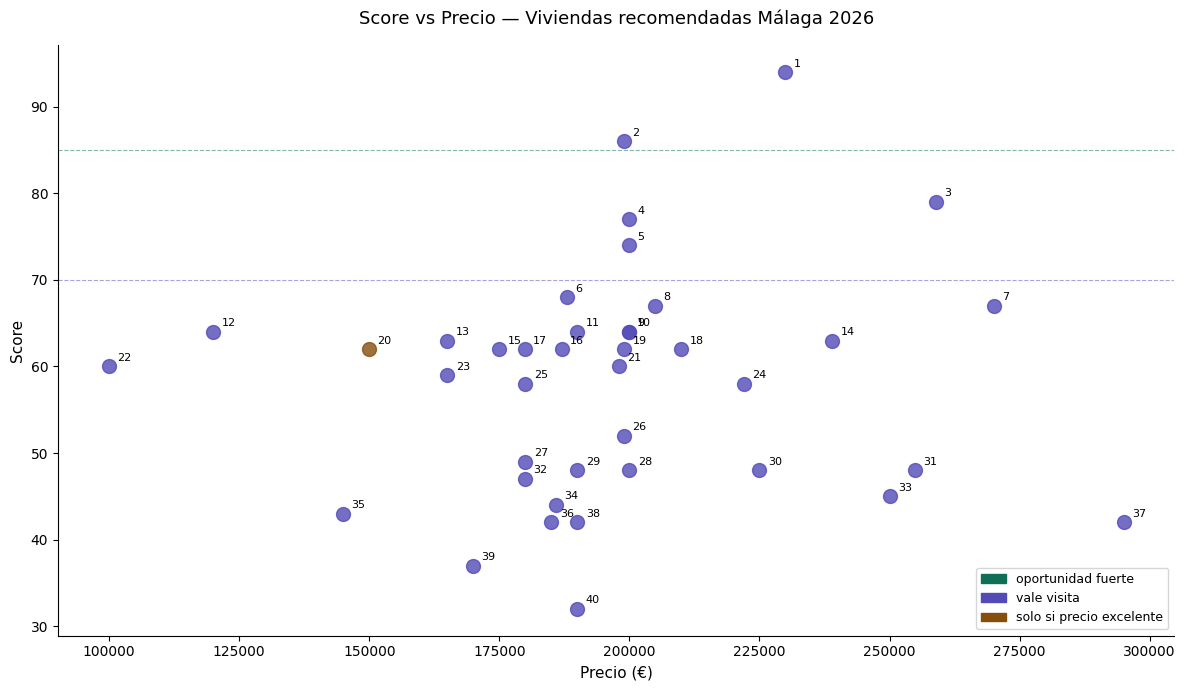

✅ Gráfico guardado


In [18]:
fig, ax = plt.subplots(figsize=(12, 7))

colores = {
    "oportunidad fuerte":       "#0F6E56",
    "vale visita":              "#534AB7",
    "solo si precio excelente": "#854F0B"
}

for _, row in df_entrega.iterrows():
    color = colores.get(row["recomendacion"], "#888")
    ax.scatter(row["precio"], row["score_total"],
               color=color, s=100, alpha=0.8, zorder=3)
    ax.annotate(
        str(row.name),
        (row["precio"], row["score_total"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8
    )

ax.axhline(85, color="#0F6E56", linestyle="--", linewidth=0.8, alpha=0.5, label="Oportunidad fuerte (85)")
ax.axhline(70, color="#534AB7", linestyle="--", linewidth=0.8, alpha=0.5, label="Vale visita (70)")

leyenda = [Patch(color=c, label=l) for l, c in colores.items()]
ax.legend(handles=leyenda, loc="lower right", fontsize=9)

ax.set_xlabel("Precio (€)", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Score vs Precio — Viviendas recomendadas Málaga 2026", fontsize=13, pad=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("data/output/score_vs_precio.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado")

#### Precio m2/zona

Precio medio €/m² por zona:


,precio_m2_medio,n_viviendas
ubicacion,,
"C. Serrano Parres, Barrio de Ciudad Jardín",1449.0,1
"La Florida - Parque norte, Málaga",1731.0,1
"Carranque - Haza Cuevas, Málaga",2206.0,1
"Ingeniero la Cierva, La Luz - El Torcal",2375.0,1
"Cruz de Humilladero, Málaga",2432.0,1
Parque Ayala - Jardín,2578.0,1
"Cruz del Humilladero - Los Tilos, Málaga",2630.0,2
La Unión - Cruz,2630.0,1
"Calvario, Torremolinos",2653.0,1


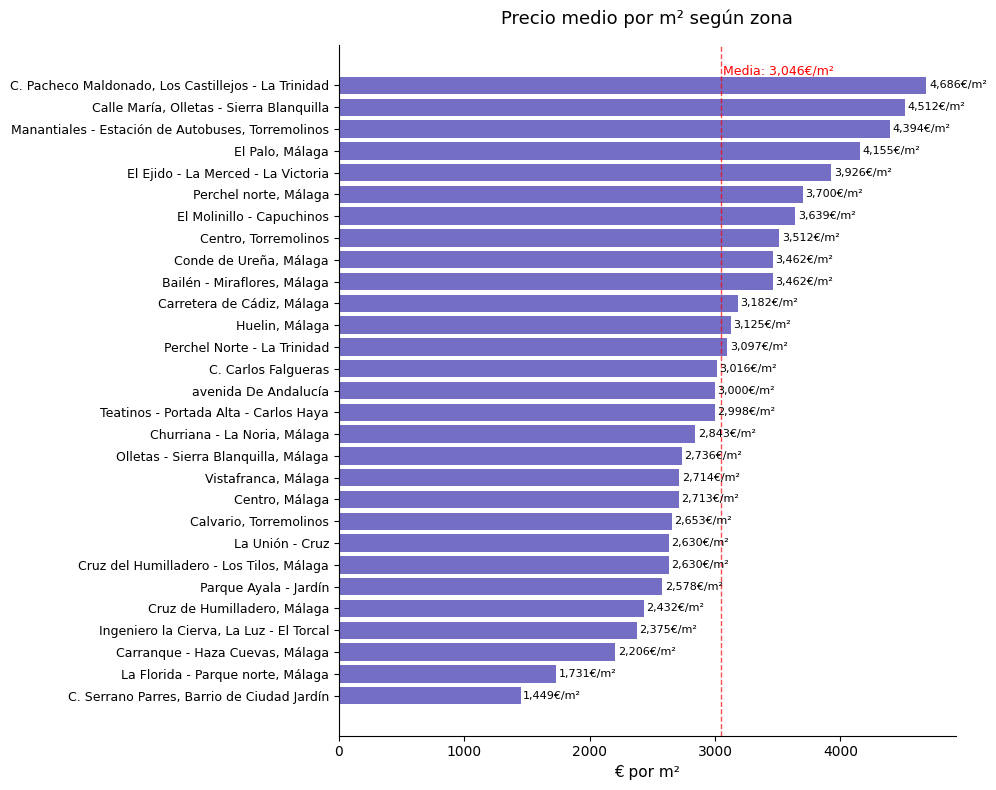

✅ Gráfico guardado


In [19]:
# Precio medio por zona
precio_zona = df_entrega.groupby("ubicacion").agg(
    precio_m2_medio = ("precio_m2", "mean"),
    n_viviendas     = ("precio_m2", "count")
).round(0).sort_values("precio_m2_medio")

print("Precio medio €/m² por zona:")
display(precio_zona)

# Gráfico precio/m² por zona
fig, ax = plt.subplots(figsize=(10, 8))
zonas = precio_zona.index.tolist()
valores = precio_zona["precio_m2_medio"].tolist()

bars = ax.barh(range(len(zonas)), valores, color="#534AB7", alpha=0.8)

ax.set_yticks(range(len(zonas)))
ax.set_yticklabels(zonas, fontsize=9)

# Valor en cada barra
for i, v in enumerate(valores):
    ax.text(v + 20, i, f"{int(v):,}€/m²", va="center", fontsize=8)

# Media general
media = df_entrega["precio_m2"].mean()
ax.axvline(media, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.text(media + 20, len(zonas) - 0.5, f"Media: {media:,.0f}€/m²", color="red", fontsize=9)

ax.set_xlabel("€ por m²", fontsize=11)
ax.set_title("Precio medio por m² según zona", fontsize=13, pad=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("data/output/precio_m2_zona.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado")

#### Guardar entregable final

In [20]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# CSV para el cliente
df_entrega.to_csv(f"data/output/entregable_cliente_{timestamp}.csv", index=True)

# Resumen ejecutivo
print("=" * 50)
print("RESUMEN EJECUTIVO — MÁLAGA 2026")
print("=" * 50)
print(f"Total viviendas analizadas:    {len(df)}")
print(f"Viviendas descartadas:         {len(df[df['recomendacion'] == 'descartar'])}")
print(f"Viviendas recomendadas:        {len(df_entrega)}")
print(f"\nPor recomendación:")
print(df_entrega["recomendacion"].value_counts().to_string())
print(f"\nPrecio medio recomendadas:     {df_entrega['precio'].mean():,.0f}€")
print(f"m² medio recomendadas:         {df_entrega['m2'].mean():,.1f}m²")
print(f"Precio/m² medio:               {df_entrega['precio_m2'].mean():,.0f}€/m²")
print(f"\nTop 3 por score:")
print(df_entrega[["score_total", "ubicacion", "precio", "m2"]].head(3).to_string())
print("=" * 50)
print(f"\n✅ Entregable guardado: entregable_cliente_{timestamp}.csv")

RESUMEN EJECUTIVO — MÁLAGA 2026
Total viviendas analizadas:    59
Viviendas descartadas:         18
Viviendas recomendadas:        40

Por recomendación:
recomendacion
vale visita                 39
solo si precio excelente     1

Precio medio recomendadas:     196,756€
m² medio recomendadas:         69.0m²
Precio/m² medio:               3,046€/m²

Top 3 por score:
      score_total                   ubicacion    precio     m2
rank                                                          
1            94.0              Centro, Málaga  230000.0  117.0
2            86.0      Calvario, Torremolinos  199000.0   75.0
3            79.0  Carretera de Cádiz, Málaga  259000.0   65.0

✅ Entregable guardado: entregable_cliente_20260524_1344.csv


In [15]:
# Top 3 por score
top3 = df_entrega.head(3)

print("TOP 3 VIVIENDAS:")
print("=" * 60)
for i, row in top3.iterrows():
    print(f"\nRank {i}")
    print(f"Score:      {row['score_total']}")
    print(f"Título:     {row['titulo']}")
    print(f"Ubicación:  {row['ubicacion']}")
    print(f"Precio:     {row['precio']:,.0f}€")
    print(f"m²:         {row['m2']}")
    print(f"URL:        {row['url']}")
    print("-" * 60)

TOP 3 VIVIENDAS:

Rank 1
Score:      94.0
Título:     Piso en venta en La Trinidad
Ubicación:  Centro, Málaga
Precio:     230,000€
m²:         117.0
URL:        https://www.idealista.com/inmueble/110912330/?utm_medium=socialmedia&utm_campaign=private_sendadtofriend&utm_source=notifications
------------------------------------------------------------

Rank 2
Score:      86.0
Título:     Piso en venta en Calle Gran Cardenal, 3
Ubicación:  Calvario, Torremolinos
Precio:     199,000€
m²:         75.0
URL:        https://www.idealista.com/inmueble/108668045/?utm_medium=socialmedia&utm_campaign=private_sendadtofriend&utm_source=notifications
------------------------------------------------------------

Rank 3
Score:      79.0
Título:     Casa o chalet independiente en venta en Nuevo San Andrés - Dos Hermanas
Ubicación:  Carretera de Cádiz, Málaga
Precio:     259,000€
m²:         65.0
URL:        https://www.idealista.com/inmueble/111155365/?utm_medium=socialmedia&utm_campaign=private_sendadt